## Student Performance analysis

### 1. Importing Libraries

In [2592]:
#Math Functions
import math

# data manipulation libraries
import numpy as np
import pandas as pd

# visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ML Algorithm's
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


# Error metrics
from sklearn.metrics import root_mean_squared_error, r2_score,mean_absolute_error,mean_squared_error

# Visualization metrics
from sklearn.tree import plot_tree


In [2593]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [2594]:
df = pd.read_csv("StudentsPerformance.csv")
df.columns = df.columns.str.replace(" ", "_", regex=False)
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2595]:
df.shape

(1000, 8)

In [2596]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [2597]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 2. Exploratory Data Analysis

In [2598]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [2599]:
df.duplicated().sum()

np.int64(0)

In [2600]:
df.nunique()

gender                          2
race/ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [2601]:
for col in df.select_dtypes(include="object"):
    print(df[col].value_counts())
    print("-"*50)

gender
female    518
male      482
Name: count, dtype: int64
--------------------------------------------------
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
--------------------------------------------------
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
--------------------------------------------------
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
--------------------------------------------------
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
--------------------------------------------------


In [2602]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

gender
['female' 'male']

race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']

parental_level_of_education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

lunch
['standard' 'free/reduced']

test_preparation_course
['none' 'completed']

math_score
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]

reading_score
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]

writing_score
[ 74  88  93  44  75  

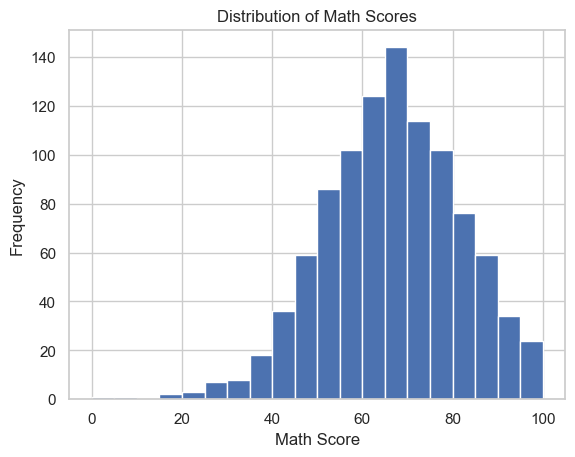

In [2603]:
plt.hist(df["math_score"], bins=20)
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.title("Distribution of Math Scores")
plt.show()

### 2.1 Univariate Analysis

#### 2.1.1 Numerical Features

In [2604]:
numeric_features = [
    "math_score",
    "reading_score",
    "writing_score"
]

categorical_features = [
    "gender",
    "race/ethnicity",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course"
]

In [2605]:
n_features = len(numeric_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

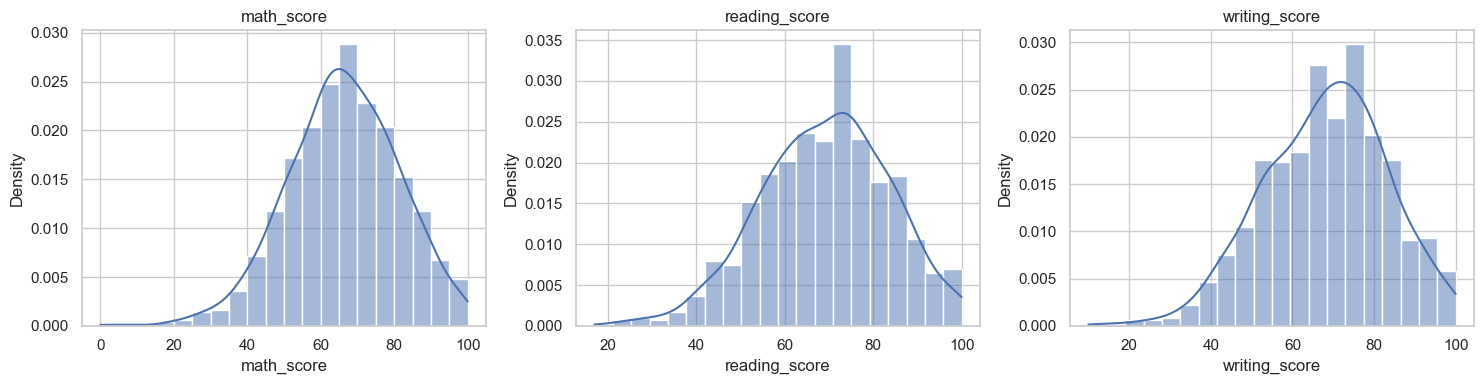

In [2606]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        stat="density",
        kde=True,
        ax=axes[i]
    )   
    axes[i].set_title(feature)

for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

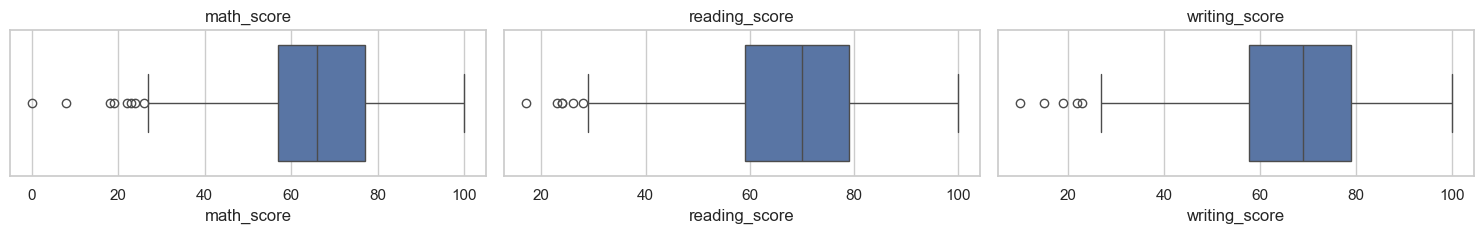

In [2607]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 2.5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        x=df[feature],
        ax=axes[i]
    )
    axes[i].set_title(feature)

# Remove unused subplots
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### 2.1.2 Categorical Features

In [2608]:
for feature in categorical_features:
    
    print("=" * 50)
    print(feature)

    freq_table = pd.DataFrame({
        "Count": df[feature].value_counts(),
        "Percentage": (df[feature].value_counts(normalize=True) * 100).round(2)
    })

    print(freq_table)
    print()

gender
        Count  Percentage
gender                   
female    518        51.8
male      482        48.2

race/ethnicity
                Count  Percentage
race/ethnicity                   
group C           319        31.9
group D           262        26.2
group B           190        19.0
group E           140        14.0
group A            89         8.9

parental_level_of_education
                             Count  Percentage
parental_level_of_education                   
some college                   226        22.6
associate's degree             222        22.2
high school                    196        19.6
some high school               179        17.9
bachelor's degree              118        11.8
master's degree                 59         5.9

lunch
              Count  Percentage
lunch                          
standard        645        64.5
free/reduced    355        35.5

test_preparation_course
                         Count  Percentage
test_preparation_course    

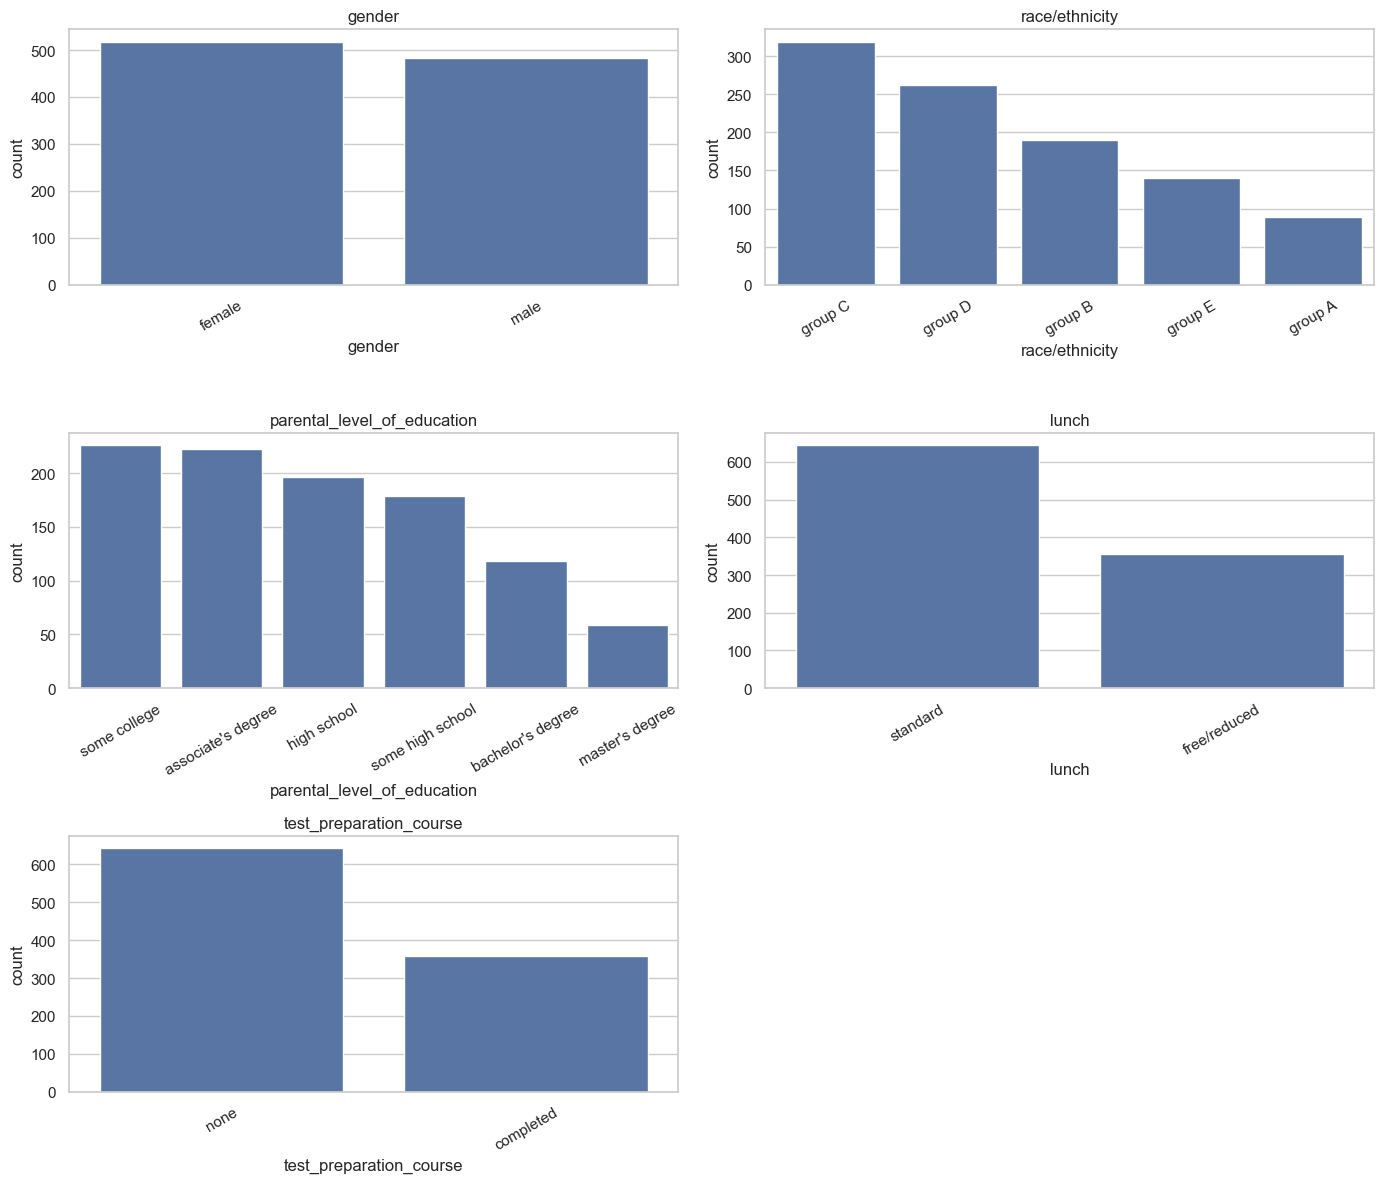

In [2609]:
n_features = len(categorical_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)


fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=30)

# Remove unused subplots
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### 2.3 Bivariate Analysis

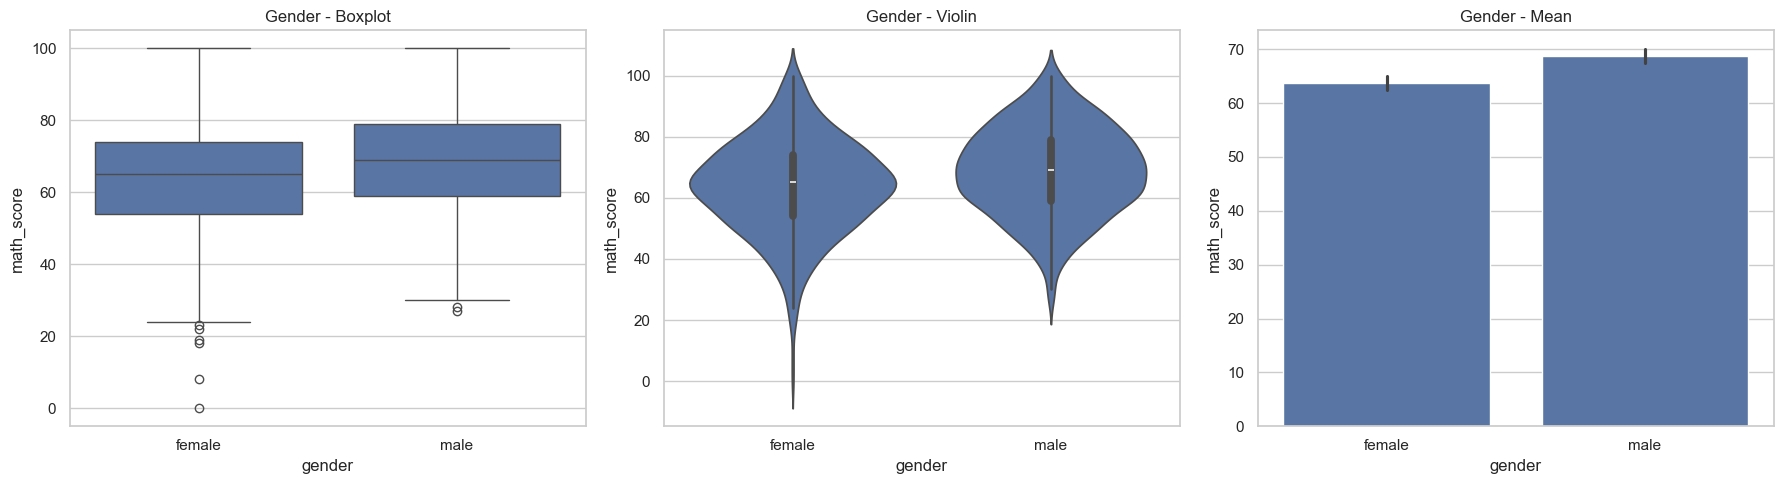

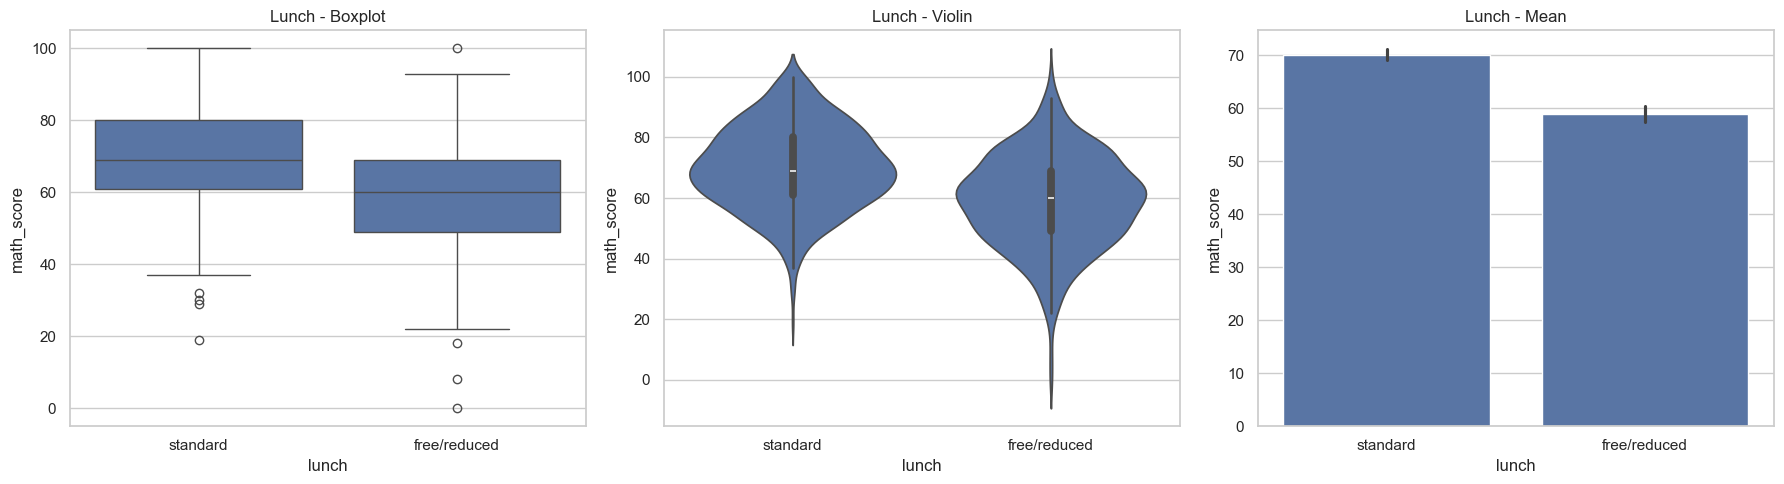

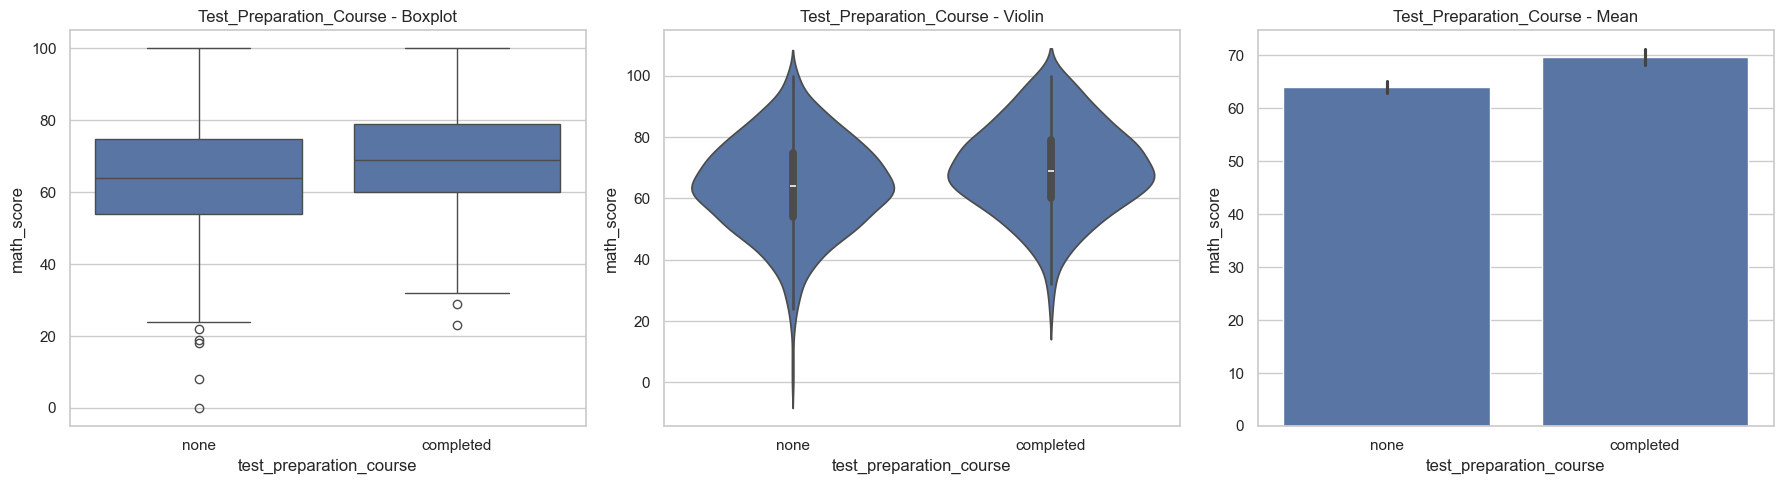

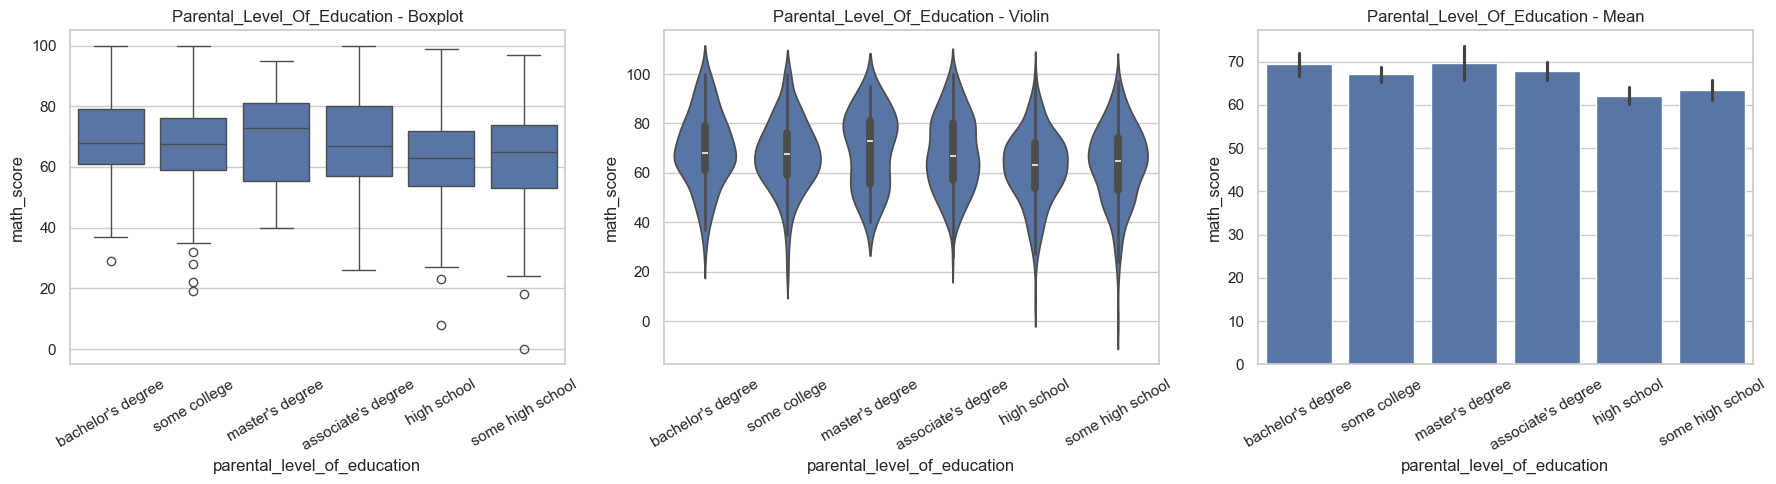

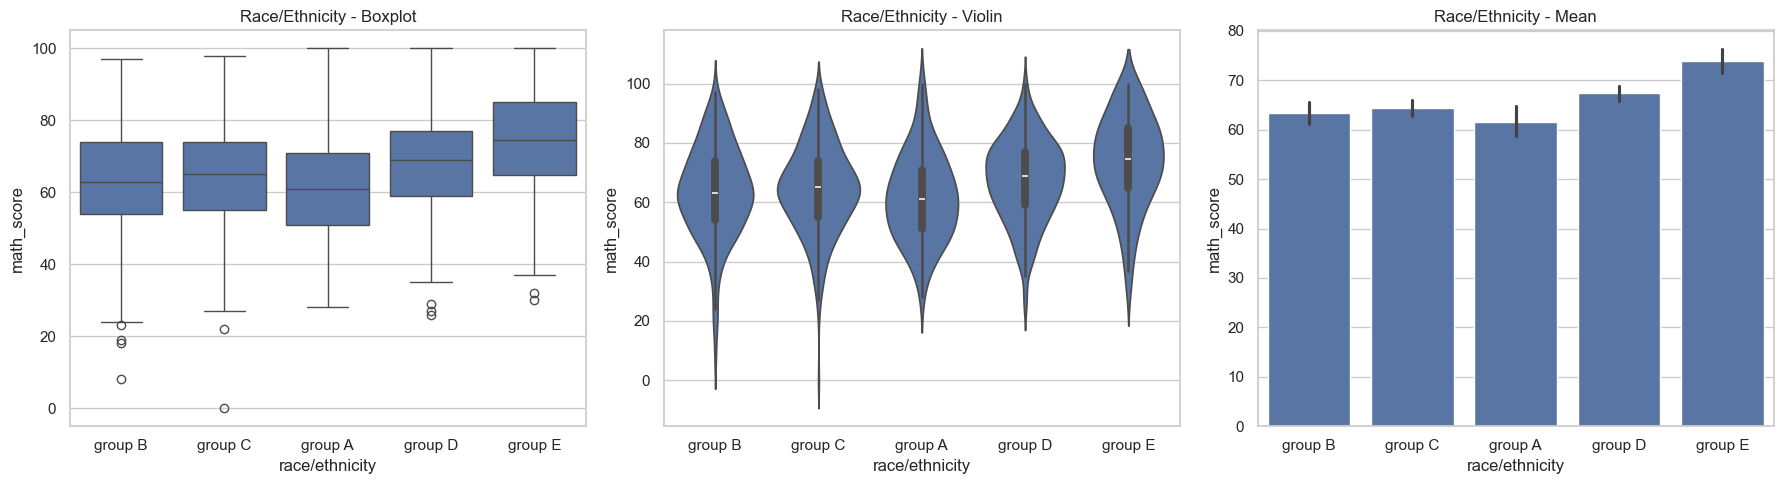

In [2610]:
categorical_features = [
    "gender",
    "lunch",
    "test_preparation_course",
    "parental_level_of_education",
    "race/ethnicity"
]

plots = [
    ("Boxplot", sns.boxplot),
    ("Violin", sns.violinplot),
    ("Mean", sns.barplot)
]

target = "math_score"

for feature in categorical_features:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, (title, plot) in zip(axes, plots):
        plot(
            data=df,
            x=feature,
            y=target,
            ax=ax
        )
        ax.set_title(f"{feature.title()} - {title}")

        if feature == "parental_level_of_education":
            ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

### 2.4 Correlation Analysis

In [2611]:
corr = df[numeric_features].corr()

corr

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


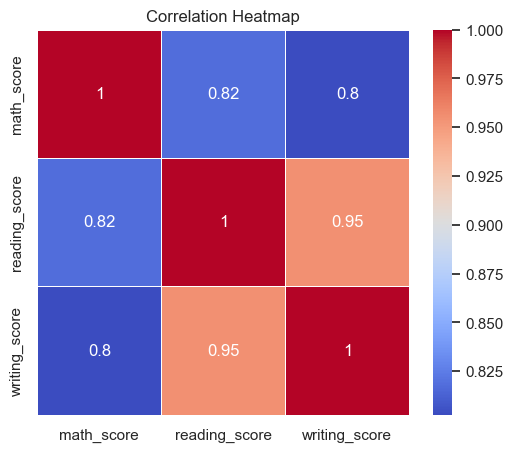

In [2612]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

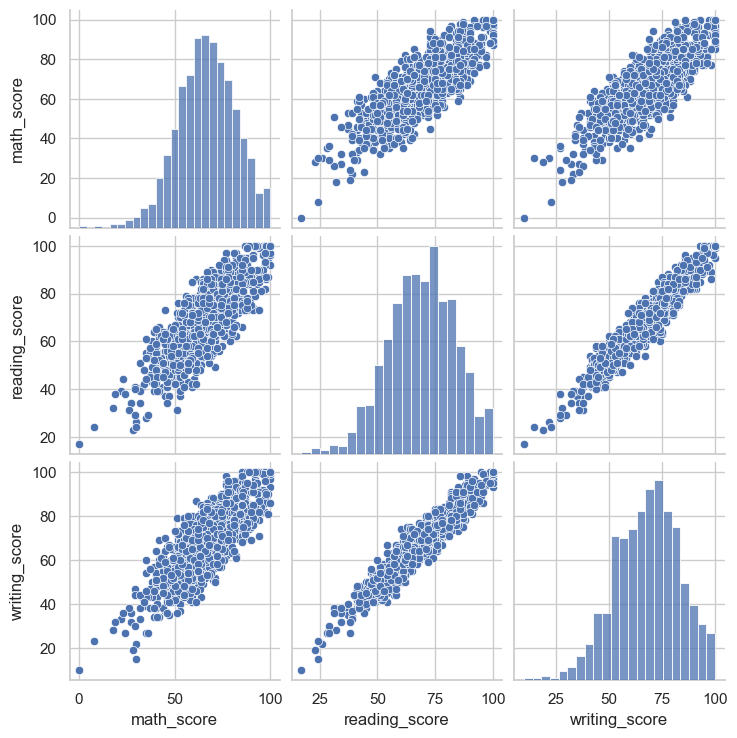

In [2613]:
sns.pairplot(df[numeric_features])

plt.show()

### 5. Outlier Detection

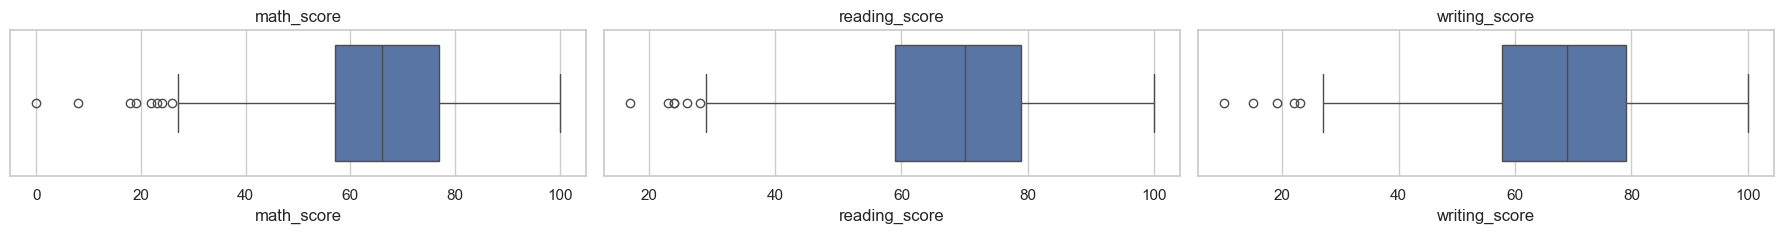

In [2614]:

n_features = len(numeric_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 2.5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        x=df[feature],
        ax=axes[i]
    )

    axes[i].set_title(feature)

# Remove unused subplots
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [2615]:
def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers

In [2616]:
for feature in numeric_features:

    outliers = detect_outliers(df, feature)

    print(feature)

    print("Number of outliers:", len(outliers))

    print("-"*40)

math_score
Number of outliers: 8
----------------------------------------
reading_score
Number of outliers: 6
----------------------------------------
writing_score
Number of outliers: 5
----------------------------------------


In [2617]:
math_outliers = detect_outliers(df, "math_score")

math_outliers.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38


### 3. Data Cleaning & Preprocessing

In [2618]:
# Check Missing Values

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
gender,0,0.0
race/ethnicity,0,0.0
parental_level_of_education,0,0.0
lunch,0,0.0
test_preparation_course,0,0.0
math_score,0,0.0
reading_score,0,0.0
writing_score,0,0.0


In [2619]:
# Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [2620]:
# Remove Duplicates

df = df.drop_duplicates()

df.shape

(1000, 8)

In [2621]:
# Separate Features and Target

X = df.drop(columns="math_score")
y = df["math_score"]

In [2622]:
numeric_features = X.select_dtypes(include="number").columns.tolist()

categorical_features = X.select_dtypes(include="object").columns.tolist()

#### 3.2 Train / Validation / Test Split

In [2623]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [2624]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

In [2625]:
print("Training :", X_train.shape)

print("Validation :", X_valid.shape)

print("Testing :", X_test.shape)

Training : (640, 7)
Validation : (160, 7)
Testing : (200, 7)


In [2626]:
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

In [2627]:
# Column Transformer
# Apply OneHotEncoder -> Categorical Columns ; StandardScaler -> Numerical Columns


scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_features),
        ("num", scaler, numeric_features)
    ]
)

In [2628]:
print(X_train.columns.tolist())

['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'reading_score', 'writing_score']


In [2629]:
print(df.columns.tolist())

['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [2630]:
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['reading_score', 'writing_score']
Categorical: ['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [2631]:
# Fit on Training Data 
X_train_processed = preprocessor.fit_transform(X_train)

# Transform Validation & Test
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

In [2632]:
print(X_train_processed.shape)

print(X_valid_processed.shape)

print(X_test_processed.shape)

(640, 14)
(160, 14)
(200, 14)


In [2633]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['cat__gender_male', 'cat__race/ethnicity_group B',
       'cat__race/ethnicity_group C', 'cat__race/ethnicity_group D',
       'cat__race/ethnicity_group E',
       "cat__parental_level_of_education_bachelor's degree",
       'cat__parental_level_of_education_high school',
       "cat__parental_level_of_education_master's degree",
       'cat__parental_level_of_education_some college',
       'cat__parental_level_of_education_some high school',
       'cat__lunch_standard', 'cat__test_preparation_course_none',
       'num__reading_score', 'num__writing_score'], dtype=object)

In [2634]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_valid_processed = pd.DataFrame(
    X_valid_processed,
    columns=feature_names,
    index=X_valid.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [2635]:
X_train_processed.head()

,cat__gender_male,cat__race/ethnicity_group B,cat__race/ethnicity_group C,cat__race/ethnicity_group D,cat__race/ethnicity_group E,cat__parental_level_of_education_bachelor's degree,cat__parental_level_of_education_high school,cat__parental_level_of_education_master's degree,cat__parental_level_of_education_some college,cat__parental_level_of_education_some high school,cat__lunch_standard,cat__test_preparation_course_none,num__reading_score,num__writing_score
390,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.164628,-0.617285
847,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,-1.068125,-1.219004
93,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.693624,-1.219004
236,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.234128,-0.082423
858,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-1.415625,-1.486434


### 4. BaseLine Model

In [2636]:
lr = LinearRegression()

lr.fit(X_train_processed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [2637]:
y_train_pred = lr.predict(X_train_processed)
y_valid_pred = lr.predict(X_valid_processed)
y_test_pred = lr.predict(X_test_processed)

In [2638]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

In [2639]:
print("Training Performance")
evaluate_model(y_train, y_train_pred)
print("Validation Performance")
evaluate_model(y_valid, y_valid_pred)

Training Performance
MAE : 4.2205
RMSE: 5.3050
R²  : 0.8769
Validation Performance
MAE : 4.4969
RMSE: 5.4502
R²  : 0.8587


In [2640]:
results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_valid, y_valid_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_valid, y_valid_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ],
    "R²": [
        r2_score(y_train, y_train_pred),
        r2_score(y_valid, y_valid_pred),
        r2_score(y_test, y_test_pred)
    ]
})

results

,Dataset,MAE,RMSE,R²
0,Train,4.220531,5.304982,0.876892
1,Validation,4.496904,5.450243,0.858716
2,Test,4.234802,5.421630,0.879205


In [2641]:
coefficients = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": lr.coef_
})

coefficients.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
0,cat__gender_male,13.381545
13,num__writing_score,11.135998
4,cat__race/ethnicity_group E,5.354559
10,cat__lunch_standard,3.483156
12,num__reading_score,3.102471
11,cat__test_preparation_course_none,2.996139
8,cat__parental_level_of_education_some college,0.920312
1,cat__race/ethnicity_group B,0.678451
6,cat__parental_level_of_education_high school,0.608068
9,cat__parental_level_of_education_some high school,0.570957


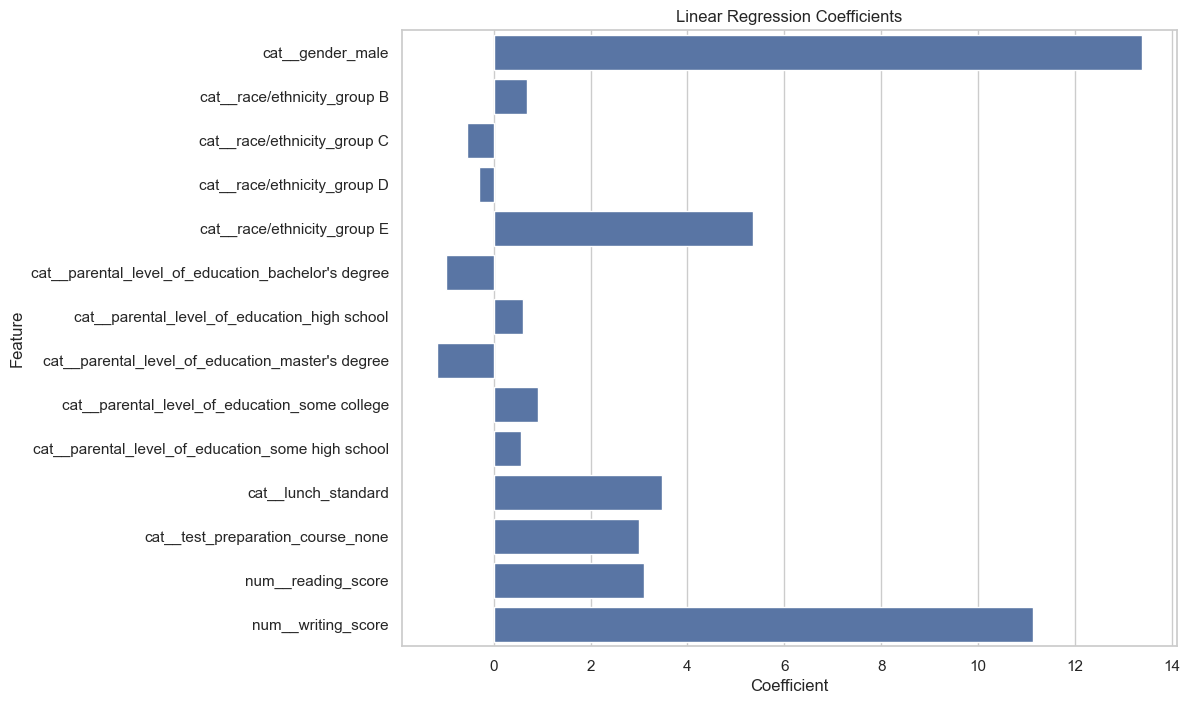

In [2642]:


plt.figure(figsize=(10,8))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")

plt.show()

In [2643]:
print("Intercept:", lr.intercept_)

Intercept: 54.70242854191312


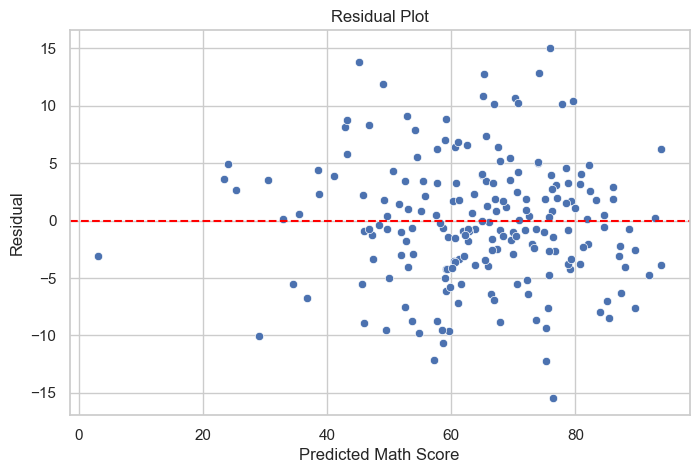

In [2644]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test_pred,
    y=residuals
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Math Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

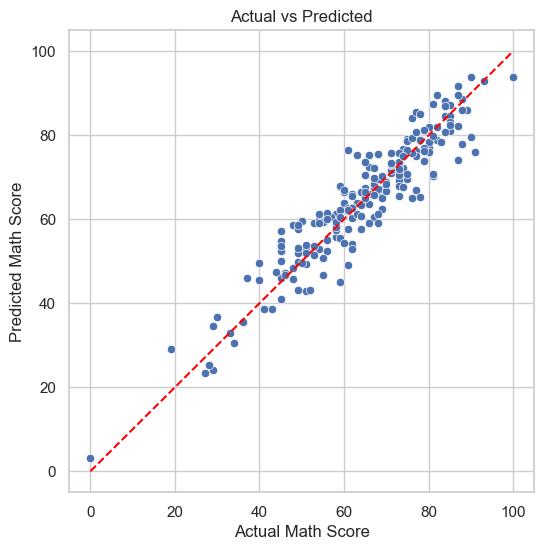

In [2645]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted")

plt.show()

In [2646]:
df_fe = df.copy()

In [2647]:
df_fe["average_literacy_score"] = (
    df_fe["reading_score"] +
    df_fe["writing_score"]
) / 2

In [2648]:
df_fe["reading_writing_gap"] = (
    df_fe["reading_score"] -
    df_fe["writing_score"]
)

In [2649]:
education_map = {
    "some high school": 0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}

df_fe["parent_education_level"] = (
    df_fe["parental_level_of_education"]
        .map(education_map)
)

In [2650]:
df_fe["prep_completed"] = (
    df_fe["test_preparation_course"]
        .map({
            "none":0,
            "completed":1
        })
)

In [2651]:
df_fe["standard_lunch"] = (
    df_fe["lunch"]
        .map({
            "free/reduced":0,
            "standard":1
        })
)

In [2652]:
df_fe["is_male"] = (
    df_fe["gender"]
        .map({
            "female":0,
            "male":1
        })
)

In [2653]:
df_fe["prep_x_lunch"] = (
    df_fe["prep_completed"] *
    df_fe["standard_lunch"]
)

In [2654]:
df_fe["prep_x_parent_education"] = (
    df_fe["prep_completed"] *
    df_fe["parent_education_level"]
)

In [2655]:
df_fe["reading_x_writing"] = (
    df_fe["reading_score"] *
    df_fe["writing_score"]
)

In [2656]:
df_fe["reading_x_parent_education"] = (
    df_fe["reading_score"] *
    df_fe["parent_education_level"]
)

In [2657]:
numeric_cols = [
    "reading_score",
    "writing_score",
    "average_literacy_score",
    "reading_writing_gap",
    
]

In [2658]:
df_fe.shape

(1000, 18)

In [2659]:
df_fe.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_literacy_score,reading_writing_gap,parent_education_level,prep_completed,standard_lunch,is_male,prep_x_lunch,prep_x_parent_education,reading_x_writing,reading_x_parent_education
0,female,group B,bachelor's degree,standard,none,72,72,74,73.0,-2,4,0,1,0,0,0,5328,288
1,female,group C,some college,standard,completed,69,90,88,89.0,2,2,1,1,0,1,2,7920,180
2,female,group B,master's degree,standard,none,90,95,93,94.0,2,5,0,1,0,0,0,8835,475
3,male,group A,associate's degree,free/reduced,none,47,57,44,50.5,13,3,0,0,1,0,0,2508,171
4,male,group C,some college,standard,none,76,78,75,76.5,3,2,0,1,1,0,0,5850,156


In [2660]:
df_fe.columns.to_list()

['gender',
 'race/ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course',
 'math_score',
 'reading_score',
 'writing_score',
 'average_literacy_score',
 'reading_writing_gap',
 'parent_education_level',
 'prep_completed',
 'standard_lunch',
 'is_male',
 'prep_x_lunch',
 'prep_x_parent_education',
 'reading_x_writing',
 'reading_x_parent_education']

In [2661]:
df_fe = df_fe.drop(
    columns=[
        "gender",
        "lunch",
        "test_preparation_course",
        "parental_level_of_education",
        
        'prep_x_parent_education',
        'prep_x_lunch',
        
        "reading_x_parent_education",
        'reading_x_writing',
        'reading_writing_gap',
        'average_literacy_score',
        'reading_writing_gap'

    ]
)

In [2663]:
df_fe.columns.to_list()

['race/ethnicity',
 'math_score',
 'reading_score',
 'writing_score',
 'parent_education_level',
 'prep_completed',
 'standard_lunch',
 'is_male']

In [2664]:
df_fe.head()

,race/ethnicity,math_score,reading_score,writing_score,parent_education_level,prep_completed,standard_lunch,is_male
0,group B,72,72,74,4,0,1,0
1,group C,69,90,88,2,1,1,0
2,group B,90,95,93,5,0,1,0
3,group A,47,57,44,3,0,0,1
4,group C,76,78,75,2,0,1,1


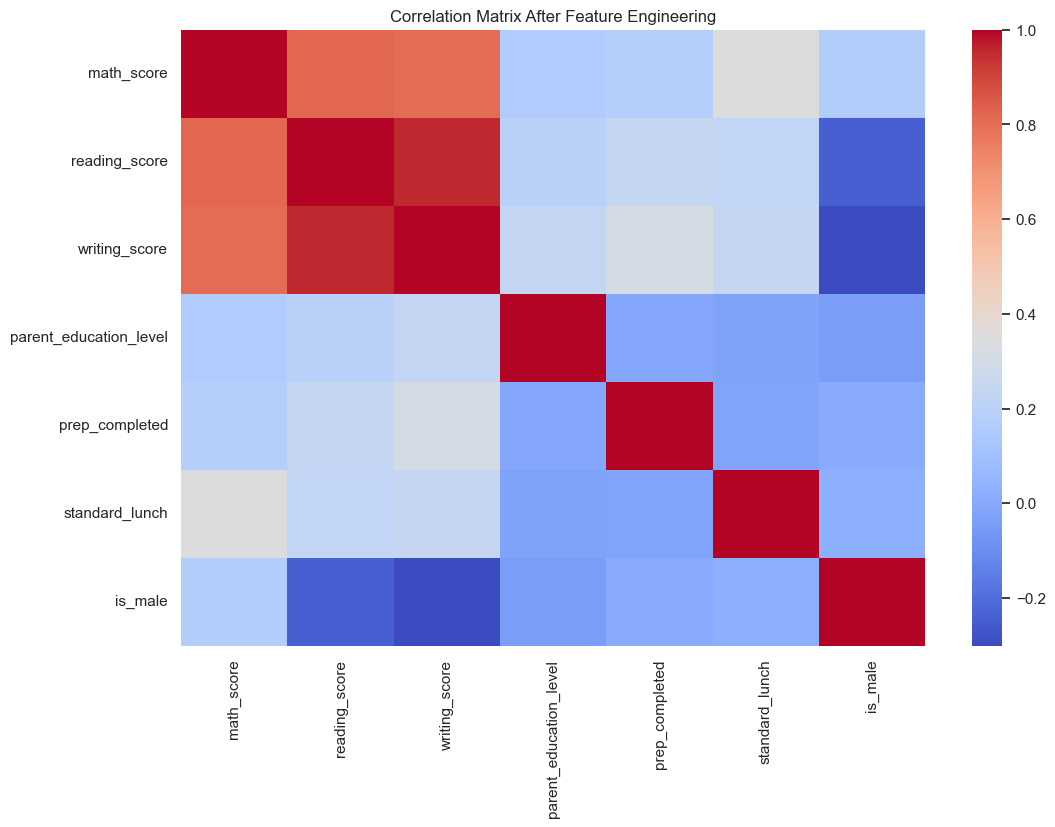

In [2665]:
corr = df_fe.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix After Feature Engineering")

plt.show()

In [2666]:
X_fe = df_fe.drop(columns="math_score")
y_fe = df_fe["math_score"]

In [2667]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

In [2668]:
print("Training :", X_train.shape)

print("Validation :", X_valid.shape)

print("Testing :", X_test.shape)

Training : (640, 7)
Validation : (160, 7)
Testing : (200, 7)


In [2669]:
numeric_features = X_fe.select_dtypes(include="number").columns.tolist()
categorical_features = X_fe.select_dtypes(include="object").columns.tolist()

In [2670]:
numeric_features

['reading_score',
 'writing_score',
 'parent_education_level',
 'prep_completed',
 'standard_lunch',
 'is_male']

In [2671]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

In [2672]:
# Fit on Training Data 
X_train_processed = preprocessor.fit_transform(X_train)

# Transform Validation & Test
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

In [2673]:
print(X_train_processed.shape)

print(X_valid_processed.shape)

print(X_test_processed.shape)

(640, 6)
(160, 6)
(200, 6)


In [2674]:
X_train_processed.shape

(640, 6)

In [2675]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=numeric_features,
    index=X_train.index
)

X_valid_processed = pd.DataFrame(
    X_valid_processed,
    columns=numeric_features,
    index=X_valid.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=numeric_features,
    index=X_test.index
)

In [2676]:
lr = LinearRegression()

lr.fit(X_train_processed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [2677]:
y_train_pred = lr.predict(X_train_processed)
y_valid_pred = lr.predict(X_valid_processed)
y_test_pred = lr.predict(X_test_processed)

In [2678]:
print("Training Performance")
evaluate_model(y_train, y_train_pred)
print("Validation Performance")
evaluate_model(y_valid, y_valid_pred)

Training Performance
MAE : 4.5280
RMSE: 5.6840
R²  : 0.8587
Validation Performance
MAE : 4.5912
RMSE: 5.5570
R²  : 0.8531


In [2679]:
results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_valid, y_valid_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_valid, y_valid_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ],
    "R²": [
        r2_score(y_train, y_train_pred),
        r2_score(y_valid, y_valid_pred),
        r2_score(y_test, y_test_pred)
    ]
})

results

,Dataset,MAE,RMSE,R²
0,Train,4.528049,5.683982,0.858674
1,Validation,4.591234,5.557005,0.853127
2,Test,4.219029,5.388366,0.880683


In [2680]:
numeric_features = X_fe.select_dtypes(include="number").columns.tolist()

categorical_features = X_fe.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),
         categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

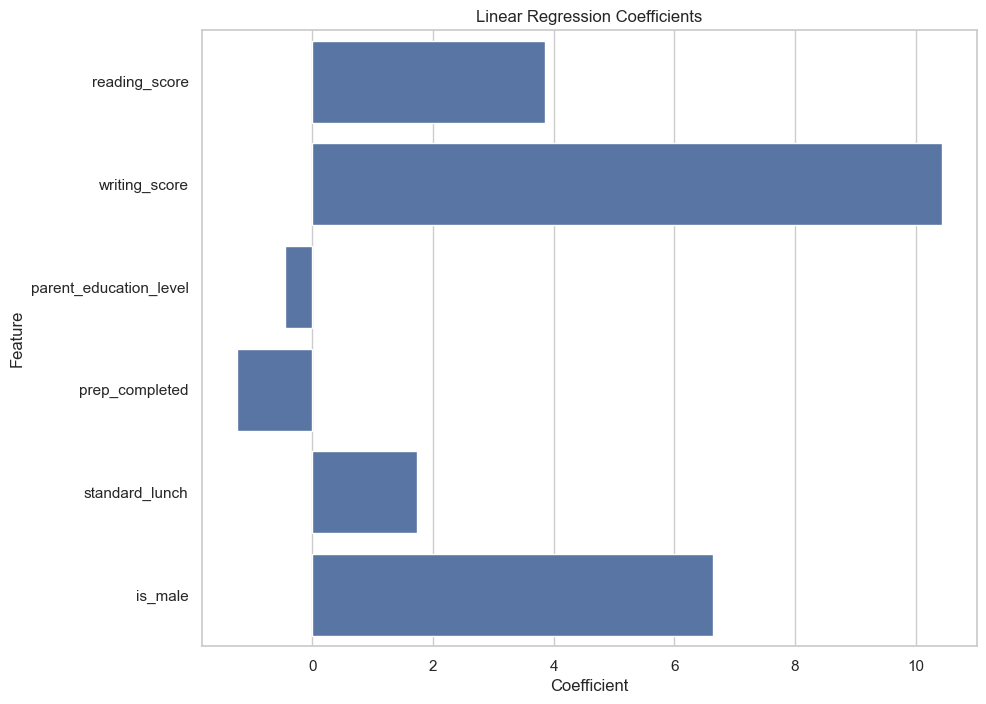

In [2681]:
coefficients = pd.DataFrame({

    "Feature": X_train_processed.columns,

    "Coefficient": lr.coef_

})



coefficients.sort_values(by="Coefficient",ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")

plt.show()

In [2682]:
def get_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

In [2683]:
ridge = Ridge(
    alpha=1.0,
    random_state=42
)

ridge.fit(X_train_processed, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [2684]:
ridge_train_pred = ridge.predict(X_train_processed)
ridge_valid_pred = ridge.predict(X_valid_processed)
ridge_test_pred = ridge.predict(X_test_processed)

In [2685]:
print("Ridge Regression")

print("\nTraining")
evaluate_model(y_train, ridge_train_pred)

print("\nValidation")
evaluate_model(y_valid, ridge_valid_pred)

print("\nTest")
evaluate_model(y_test, ridge_test_pred)

Ridge Regression

Training
MAE : 4.5267
RMSE: 5.6842
R²  : 0.8587

Validation
MAE : 4.5878
RMSE: 5.5537
R²  : 0.8533

Test
MAE : 4.2185
RMSE: 5.3881
R²  : 0.8807


In [2686]:
lasso = Lasso(
    alpha=0.01,
    random_state=42,
    max_iter=10000
)

lasso.fit(X_train_processed, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [2687]:
lasso_train_pred = lasso.predict(X_train_processed)
lasso_valid_pred = lasso.predict(X_valid_processed)
lasso_test_pred = lasso.predict(X_test_processed)

In [2688]:
print("Lasso Regression")

print("\nTraining")
evaluate_model(y_train, lasso_train_pred)

print("\nValidation")
evaluate_model(y_valid, lasso_valid_pred)

print("\nTest")
evaluate_model(y_test, lasso_test_pred)

Lasso Regression

Training
MAE : 4.5274
RMSE: 5.6841
R²  : 0.8587

Validation
MAE : 4.5919
RMSE: 5.5581
R²  : 0.8531

Test
MAE : 4.2197
RMSE: 5.3900
R²  : 0.8806


In [2689]:
elastic = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    random_state=42,
    max_iter=10000
)

elastic.fit(X_train_processed, y_train)

,alpha,0.01
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,10000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [2690]:
elastic_train_pred = elastic.predict(X_train_processed)
elastic_valid_pred = elastic.predict(X_valid_processed)
elastic_test_pred = elastic.predict(X_test_processed)

In [2691]:
print("ElasticNet")

print("\nTraining")
evaluate_model(y_train, elastic_train_pred)

print("\nValidation")
evaluate_model(y_valid, elastic_valid_pred)

print("\nTest")
evaluate_model(y_test, elastic_test_pred)

ElasticNet

Training
MAE : 4.5243
RMSE: 5.6860
R²  : 0.8586

Validation
MAE : 4.5813
RMSE: 5.5494
R²  : 0.8535

Test
MAE : 4.2203
RMSE: 5.3905
R²  : 0.8806


In [2692]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "ElasticNet"
    ],

    "MAE": [
        mean_absolute_error(y_test, y_test_pred),
        mean_absolute_error(y_test, ridge_test_pred),
        mean_absolute_error(y_test, lasso_test_pred),
        mean_absolute_error(y_test, elastic_test_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_test_pred)),
        np.sqrt(mean_squared_error(y_test, elastic_test_pred))
    ],

    "R²": [
        r2_score(y_test, y_test_pred),
        r2_score(y_test, ridge_test_pred),
        r2_score(y_test, lasso_test_pred),
        r2_score(y_test, elastic_test_pred)
    ]
})

comparison.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
1,Ridge,4.218475,5.388052,0.880697
0,Linear Regression,4.219029,5.388366,0.880683
2,Lasso,4.219713,5.390027,0.880609
3,ElasticNet,4.220263,5.390455,0.880590


In [2693]:
ridge_coef = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": ridge.coef_
}).sort_values("Coefficient", ascending=False)

ridge_coef

,Feature,Coefficient
1,writing_score,10.261140
5,is_male,6.606004
0,reading_score,4.002666
4,standard_lunch,1.737608
2,parent_education_level,-0.441257
3,prep_completed,-1.229039


In [2694]:
lasso_coef = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": lasso.coef_
}).sort_values("Coefficient", ascending=False)

lasso_coef

,Feature,Coefficient
1,writing_score,10.372340
5,is_male,6.616076
0,reading_score,3.899138
4,standard_lunch,1.725542
2,parent_education_level,-0.438521
3,prep_completed,-1.231132


In [2695]:
elastic_coef = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": elastic.coef_
}).sort_values("Coefficient", ascending=False)

elastic_coef

,Feature,Coefficient
1,writing_score,9.897698
5,is_male,6.536709
0,reading_score,4.289932
4,standard_lunch,1.758635
2,parent_education_level,-0.409484
3,prep_completed,-1.175247


In [2696]:
print("Original Features :", len(lasso.coef_))
print("Selected Features :", np.sum(lasso.coef_ != 0))

Original Features : 6
Selected Features : 6


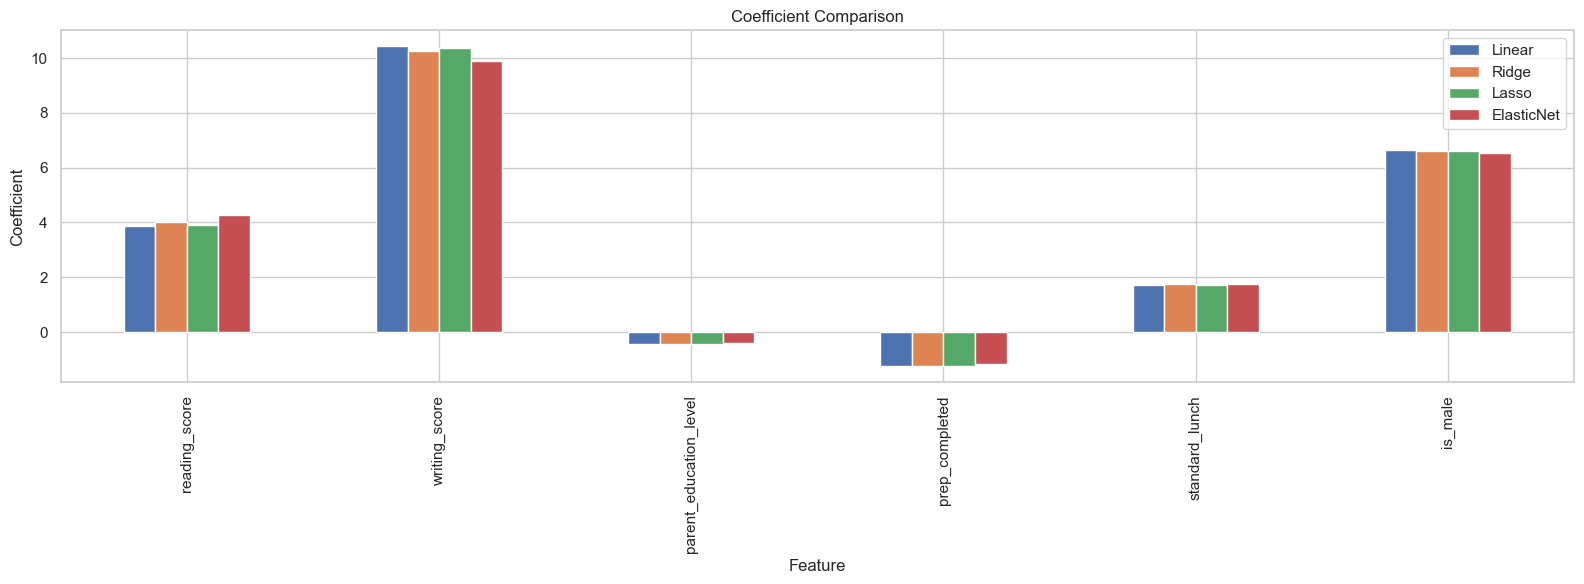

In [2697]:
coef_df = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})

coef_df.set_index("Feature").plot(
    kind="bar",
    figsize=(16,6)
)

plt.ylabel("Coefficient")
plt.title("Coefficient Comparison")
plt.tight_layout()
plt.show()

In [2698]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train_processed, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [2699]:
y_train_pred = dt.predict(X_train_processed)
y_valid_pred = dt.predict(X_valid_processed)
y_test_pred = dt.predict(X_test_processed)

In [2700]:
print("Training")
evaluate_model(y_train, y_train_pred)

print("\nValidation")
evaluate_model(y_valid, y_valid_pred)

print("\nTest")
evaluate_model(y_test, y_test_pred)

Training
MAE : 0.0547
RMSE: 0.6117
R²  : 0.9984

Validation
MAE : 6.4250
RMSE: 8.1386
R²  : 0.6850

Test
MAE : 6.5575
RMSE: 8.2135
R²  : 0.7228


In [2701]:
best_dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

best_dt.fit(X_train_processed, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [2702]:
train_pred = best_dt.predict(X_train_processed)
valid_pred = best_dt.predict(X_valid_processed)
test_pred = best_dt.predict(X_test_processed)

print("Training")
evaluate_model(y_train, train_pred)

print("\nValidation")
evaluate_model(y_valid, valid_pred)

print("\nTest")
evaluate_model(y_test, test_pred)

Training
MAE : 4.5799
RMSE: 5.7321
R²  : 0.8563

Validation
MAE : 5.4998
RMSE: 6.7614
R²  : 0.7826

Test
MAE : 5.0689
RMSE: 6.5446
R²  : 0.8240


In [2703]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

In [2704]:
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [2705]:
print(grid.best_params_)

{'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [2706]:
best_dt = grid.best_estimator_

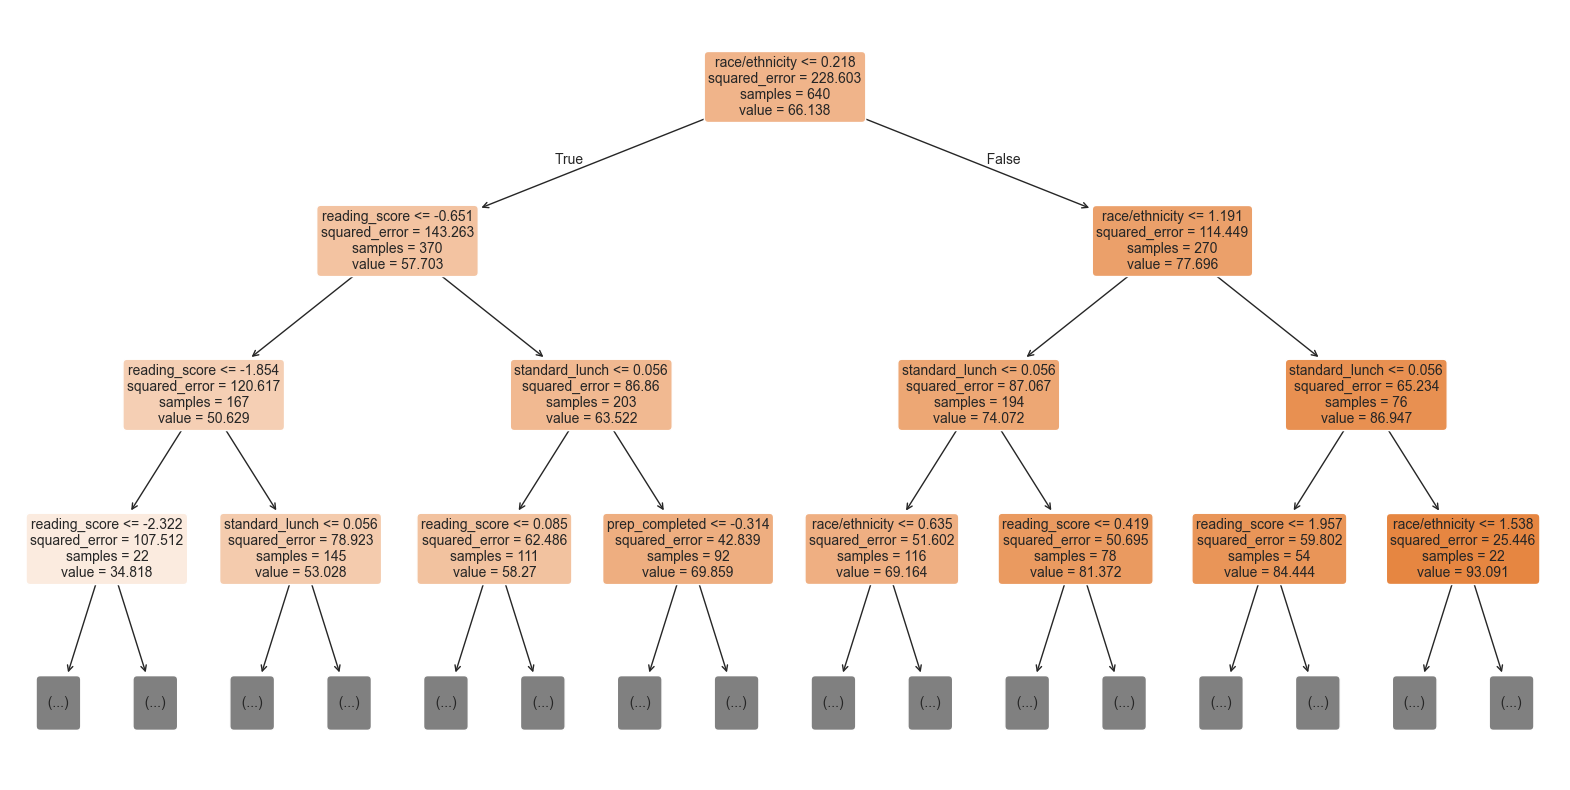

In [2707]:
plt.figure(figsize=(20,10))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.show()

In [2708]:
importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": best_dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,reading_score,0.582967
1,writing_score,0.246653
5,is_male,0.142177
4,standard_lunch,0.017679
2,parent_education_level,0.005397
3,prep_completed,0.005127


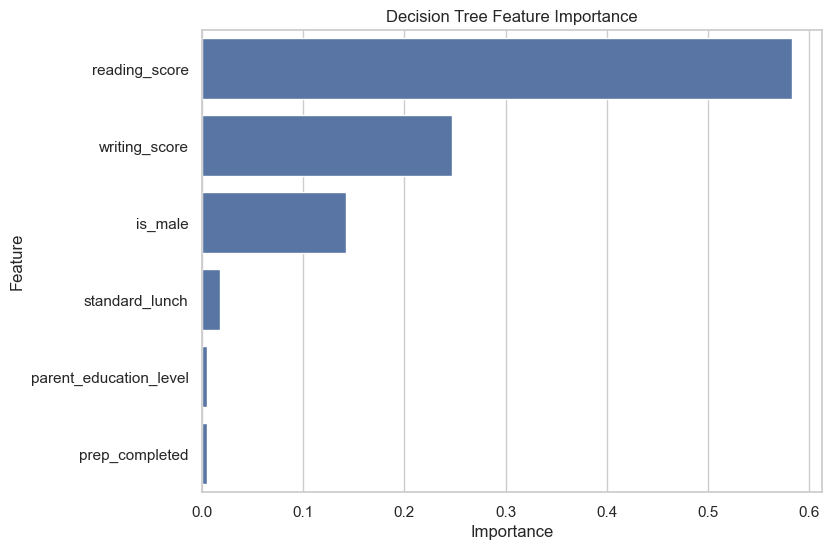

In [2709]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")

plt.show()

In [2710]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [2711]:
rf_train_pred = rf.predict(X_train_processed)
rf_valid_pred = rf.predict(X_valid_processed)
rf_test_pred = rf.predict(X_test_processed)

In [2712]:
print("Training")
evaluate_model(y_train, rf_train_pred)

print("\nValidation")
evaluate_model(y_valid, rf_valid_pred)

print("\nTest")
evaluate_model(y_test, rf_test_pred)

Training
MAE : 1.9259
RMSE: 2.4690
R²  : 0.9733

Validation
MAE : 4.8511
RMSE: 6.2023
R²  : 0.8170

Test
MAE : 4.8751
RMSE: 6.3012
R²  : 0.8368


In [2713]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 2, 5]
}

In [2714]:
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train_processed, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [2715]:
print(grid_rf.best_params_)

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}


In [2716]:
best_rf = grid_rf.best_estimator_

In [2717]:
rf_train_pred = best_rf.predict(X_train_processed)
rf_valid_pred = best_rf.predict(X_valid_processed)
rf_test_pred = best_rf.predict(X_test_processed)

print("Training")
evaluate_model(y_train, rf_train_pred)

print("\nValidation")
evaluate_model(y_valid, rf_valid_pred)

print("\nTest")
evaluate_model(y_test, rf_test_pred)

Training
MAE : 3.3273
RMSE: 4.1920
R²  : 0.9231

Validation
MAE : 4.7669
RMSE: 5.9917
R²  : 0.8293

Test
MAE : 4.8257
RMSE: 6.2479
R²  : 0.8396


In [2718]:
importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,reading_score,0.404330
1,writing_score,0.386334
5,is_male,0.102199
4,standard_lunch,0.063055
2,parent_education_level,0.028472
3,prep_completed,0.015610


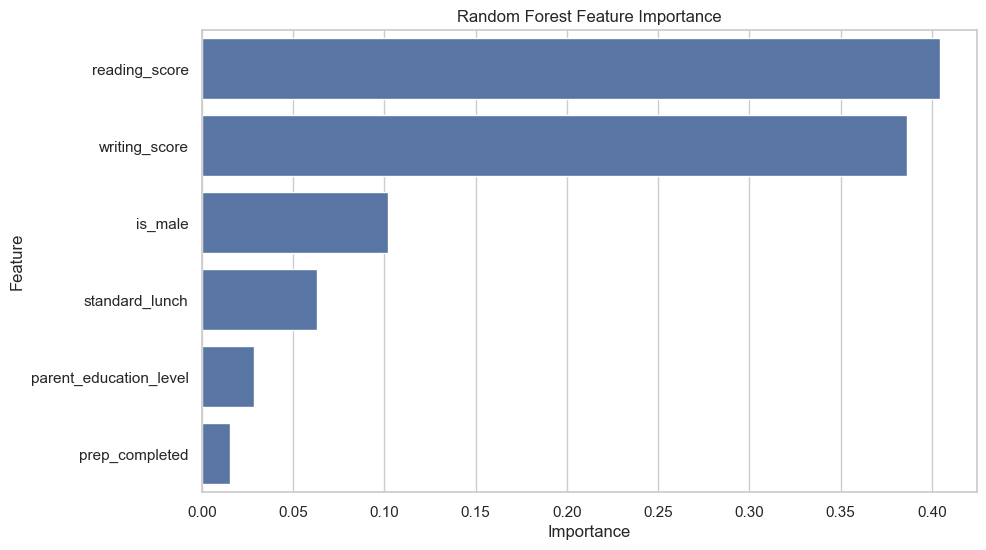

In [2719]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [2720]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr.predict(X_test_processed)),
        mean_absolute_error(y_test, ridge.predict(X_test_processed)),
        mean_absolute_error(y_test, lasso.predict(X_test_processed)),
        mean_absolute_error(y_test, elastic.predict(X_test_processed)),
        mean_absolute_error(y_test, best_dt.predict(X_test_processed)),
        mean_absolute_error(y_test, best_rf.predict(X_test_processed))
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, elastic.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, best_dt.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test_processed)))
    ],
    "R²": [
        r2_score(y_test, lr.predict(X_test_processed)),
        r2_score(y_test, ridge.predict(X_test_processed)),
        r2_score(y_test, lasso.predict(X_test_processed)),
        r2_score(y_test, elastic.predict(X_test_processed)),
        r2_score(y_test, best_dt.predict(X_test_processed)),
        r2_score(y_test, best_rf.predict(X_test_processed))
    ]
})

comparison.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
1,Ridge,4.218475,5.388052,0.880697
0,Linear Regression,4.219029,5.388366,0.880683
2,Lasso,4.219713,5.390027,0.880609
3,ElasticNet,4.220263,5.390455,0.880590
5,Random Forest,4.825691,6.247869,0.839582
4,Decision Tree,5.086097,6.435922,0.829780


In [2721]:
gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train_processed, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [2722]:
gbr_train_pred = gbr.predict(X_train_processed)
gbr_valid_pred = gbr.predict(X_valid_processed)
gbr_test_pred = gbr.predict(X_test_processed)

In [2723]:
print("Training")
evaluate_model(y_train, gbr_train_pred)

print("\nValidation")
evaluate_model(y_valid, gbr_valid_pred)

print("\nTest")
evaluate_model(y_test, gbr_test_pred)

Training
MAE : 3.8239
RMSE: 4.7825
R²  : 0.8999

Validation
MAE : 4.6667
RMSE: 5.8321
R²  : 0.8382

Test
MAE : 4.3670
RMSE: 5.6150
R²  : 0.8704


In [2724]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [2725]:
grid_gbr = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_gbr.fit(X_train_processed, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [2726]:
print(grid_gbr.best_params_)

{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [2727]:
best_gbr = grid_gbr.best_estimator_

In [2728]:
gbr_train_pred = best_gbr.predict(X_train_processed)
gbr_valid_pred = best_gbr.predict(X_valid_processed)
gbr_test_pred = best_gbr.predict(X_test_processed)

print("Training")
evaluate_model(y_train, gbr_train_pred)

print("\nValidation")
evaluate_model(y_valid, gbr_valid_pred)

print("\nTest")
evaluate_model(y_test, gbr_test_pred)

Training
MAE : 4.2482
RMSE: 5.3003
R²  : 0.8771

Validation
MAE : 4.6540
RMSE: 5.7516
R²  : 0.8427

Test
MAE : 4.3410
RMSE: 5.5901
R²  : 0.8716


In [2729]:
importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": best_gbr.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,reading_score,0.504221
1,writing_score,0.295103
5,is_male,0.154258
4,standard_lunch,0.041538
3,prep_completed,0.003309
2,parent_education_level,0.001571


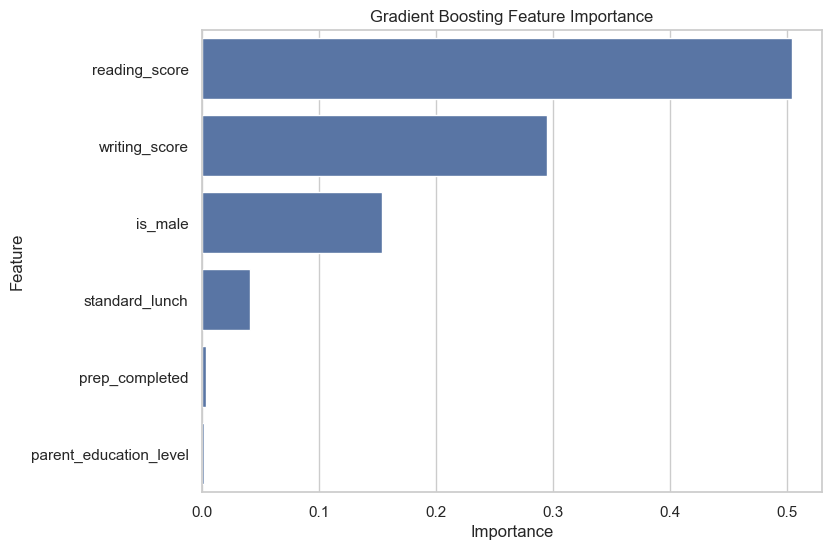

In [2730]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")

plt.show()

In [2731]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train_processed, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [2732]:
xgb_train_pred = xgb.predict(X_train_processed)
xgb_valid_pred = xgb.predict(X_valid_processed)
xgb_test_pred = xgb.predict(X_test_processed)

In [2733]:
print("Training")
evaluate_model(y_train, xgb_train_pred)

print("\nValidation")
evaluate_model(y_valid, xgb_valid_pred)

print("\nTest")
evaluate_model(y_test, xgb_test_pred)

Training
MAE : 0.8119
RMSE: 1.2584
R²  : 0.9931

Validation
MAE : 5.2668
RMSE: 6.6629
R²  : 0.7889

Test
MAE : 5.4553
RMSE: 6.8871
R²  : 0.8051


In [2734]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [2735]:
grid_xgb = GridSearchCV(
    XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train_processed, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [2736]:
print(grid_xgb.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [2737]:
best_xgb = grid_xgb.best_estimator_

In [2738]:
xgb_train_pred = best_xgb.predict(X_train_processed)
xgb_valid_pred = best_xgb.predict(X_valid_processed)
xgb_test_pred = best_xgb.predict(X_test_processed)

print("Training")
evaluate_model(y_train, xgb_train_pred)

print("\nValidation")
evaluate_model(y_valid, xgb_valid_pred)

print("\nTest")
evaluate_model(y_test, xgb_test_pred)

Training
MAE : 3.8807
RMSE: 4.8373
R²  : 0.8976

Validation
MAE : 4.6910
RMSE: 5.8461
R²  : 0.8374

Test
MAE : 4.4147
RMSE: 5.7144
R²  : 0.8658


In [2739]:
importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,reading_score,0.303029
5,is_male,0.277987
1,writing_score,0.221901
4,standard_lunch,0.159898
3,prep_completed,0.022254
2,parent_education_level,0.014931


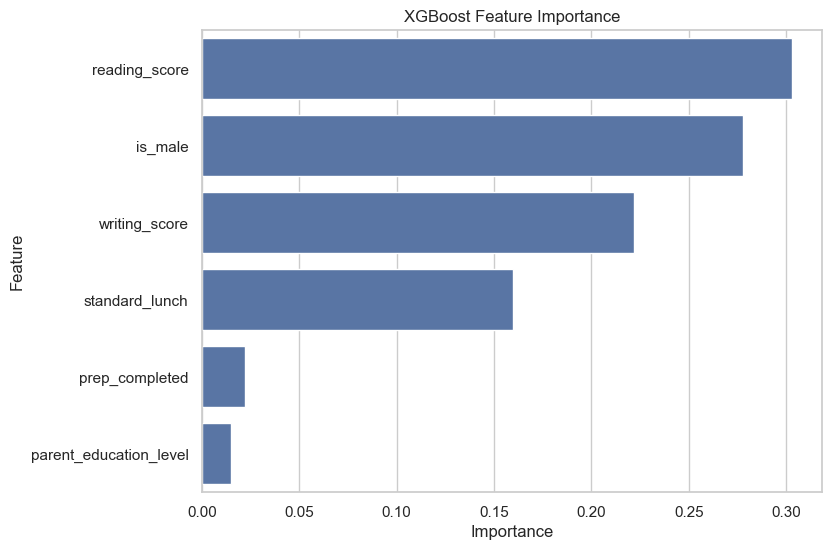

In [2740]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.show()

In [2741]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr.predict(X_test_processed)),
        mean_absolute_error(y_test, ridge.predict(X_test_processed)),
        mean_absolute_error(y_test, lasso.predict(X_test_processed)),
        mean_absolute_error(y_test, elastic.predict(X_test_processed)),
        mean_absolute_error(y_test, best_dt.predict(X_test_processed)),
        mean_absolute_error(y_test, best_rf.predict(X_test_processed)),
        mean_absolute_error(y_test, best_gbr.predict(X_test_processed)),
        mean_absolute_error(y_test, best_xgb.predict(X_test_processed))
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, elastic.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, best_dt.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, best_gbr.predict(X_test_processed))),
        np.sqrt(mean_squared_error(y_test, best_xgb.predict(X_test_processed)))
    ],
    "R²": [
        r2_score(y_test, lr.predict(X_test_processed)),
        r2_score(y_test, ridge.predict(X_test_processed)),
        r2_score(y_test, lasso.predict(X_test_processed)),
        r2_score(y_test, elastic.predict(X_test_processed)),
        r2_score(y_test, best_dt.predict(X_test_processed)),
        r2_score(y_test, best_rf.predict(X_test_processed)),
        r2_score(y_test, best_gbr.predict(X_test_processed)),
        r2_score(y_test, best_xgb.predict(X_test_processed))
    ]
})

comparison = comparison.sort_values("R²", ascending=False)
comparison

,Model,MAE,RMSE,R²
1,Ridge,4.218475,5.388052,0.880697
0,Linear Regression,4.219029,5.388366,0.880683
2,Lasso,4.219713,5.390027,0.880609
3,ElasticNet,4.220263,5.390455,0.880590
6,Gradient Boosting,4.341017,5.590086,0.871582
7,XGBoost,4.414743,5.714365,0.865808
5,Random Forest,4.825691,6.247869,0.839582
4,Decision Tree,5.086097,6.435922,0.829780


In [2742]:
input_dim = X_train_processed.shape[1]

print(input_dim)

6


In [2743]:
model = Sequential([
    
    Dense(
        64,
        activation="relu",
        input_shape=(input_dim,)
    ),

    BatchNormalization(),

    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

c:\Users\Gokul Ananth\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [2744]:
model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=[
        tf.keras.metrics.RootMeanSquaredError()
    ]
)

In [2745]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [2746]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    verbose=1
)

In [2747]:
history = model.fit(
    X_train_processed,
    y_train,

    validation_data=(
        X_valid_processed,
        y_valid
    ),

    epochs=300,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4368.7871 - root_mean_squared_error: 66.0968 - val_loss: 4674.8784 - val_root_mean_squared_error: 68.3731 - learning_rate: 0.0010
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4219.7617 - root_mean_squared_error: 64.9597 - val_loss: 4603.8892 - val_root_mean_squared_error: 67.8520 - learning_rate: 0.0010
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4040.5098 - root_mean_squared_error: 63.5650 - val_loss: 4482.5103 - val_root_mean_squared_error: 66.9516 - learning_rate: 0.0010
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3838.8308 - root_mean_squared_error: 61.9583 - val_loss: 4301.5088 - val_root_mean_squared_error: 65.5859 - learning_rate: 0.0010
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3591.1570 - root_mean_squared_error: 59.9263 - val_loss: 4055.7695 - val_root_mean_squared_error: 63.6849 - learning_rate: 0.0010
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

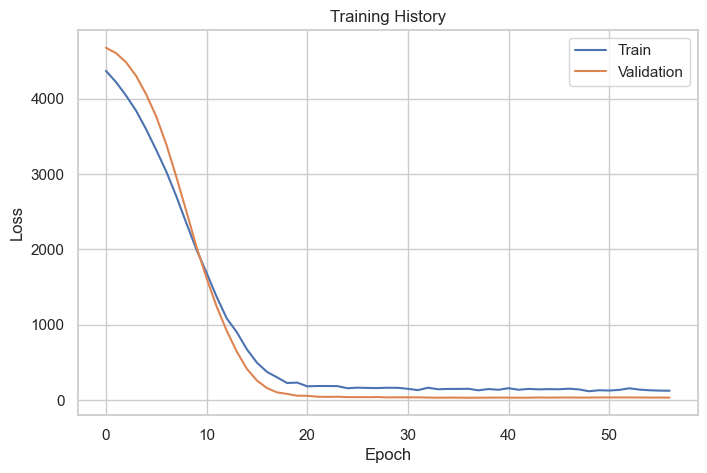

In [2748]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.title("Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [2749]:
train_pred = model.predict(X_train_processed)

valid_pred = model.predict(X_valid_processed)

test_pred = model.predict(X_test_processed)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [2750]:
print("Training")

evaluate_model(
    y_train,
    train_pred
)

print()

print("Validation")

evaluate_model(
    y_valid,
    valid_pred
)

print()

print("Test")

evaluate_model(
    y_test,
    test_pred
)

Training
MAE : 4.6381
RMSE: 5.8822
R²  : 0.8486

Validation
MAE : 4.5951
RMSE: 5.6364
R²  : 0.8489

Test
MAE : 4.6217
RMSE: 6.1164
R²  : 0.8463


In [2751]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,989 (39.02 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 6,532 (25.52 KB)

In [2752]:
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,20,None],
    "min_samples_leaf":[1,2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}


In [2753]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),

    param_distributions={
        "n_estimators":[100,200,300,500],
        "learning_rate":[0.001,0.01,0.05,0.1],
        "max_depth":[3,5,7,9],
        "subsample":[0.6,0.8,1.0]
    },

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train_processed,
    y_train
)

print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


In [2754]:
model_results = []
model_results

[]

In [2755]:
def add_results(model_name, y_true, y_pred):
    model_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    })

In [2756]:
model_results

[]

In [2757]:
# Linear Regression
add_results(
    "Linear Regression",
    y_test,
    lr.predict(X_test_processed)
)

# Ridge
add_results(
    "Ridge",
    y_test,
    ridge.predict(X_test_processed)
)

# Lasso
add_results(
    "Lasso",
    y_test,
    lasso.predict(X_test_processed)
)

# ElasticNet
add_results(
    "ElasticNet",
    y_test,
    elastic.predict(X_test_processed)
)

# Decision Tree
add_results(
    "Decision Tree",
    y_test,
    best_dt.predict(X_test_processed)
)

# Random Forest
add_results(
    "Random Forest",
    y_test,
    best_rf.predict(X_test_processed)
)

# Gradient Boosting
add_results(
    "Gradient Boosting",
    y_test,
    best_gbr.predict(X_test_processed)
)

# XGBoost
add_results(
    "XGBoost",
    y_test,
    best_xgb.predict(X_test_processed)
)


# Neural Network
nn_pred = model.predict(X_test_processed).flatten()

add_results(
    "Neural Network",
    y_test,
    nn_pred
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [2758]:
comparison = (
    pd.DataFrame(model_results)
      .sort_values(by="R²", ascending=False)
      .reset_index(drop=True)
)

comparison

,Model,MAE,RMSE,R²
0,Ridge,4.218475,5.388052,0.880697
1,Linear Regression,4.219029,5.388366,0.880683
2,Lasso,4.219713,5.390027,0.880609
3,ElasticNet,4.220263,5.390455,0.880590
4,Gradient Boosting,4.341017,5.590086,0.871582
5,XGBoost,4.414743,5.714365,0.865808
6,Neural Network,4.621748,6.116392,0.846262
7,Random Forest,4.825691,6.247869,0.839582
8,Decision Tree,5.086097,6.435922,0.829780
